In [2]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#loading the dataset
df = pd.read_csv("openfoodfacts_nutrition_final_2025-12-10.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9804
Columns: 20


In [4]:
#Look at the Dataset
df.head()

,code,product_name,brands,countries,quantity,categories,labels,nutriscore_grade,ecoscore_grade,nova_group,ingredients_text,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,6111035000430,Sidi Ali,سيدي علي,Morocco,33 cl,"Beverages and beverages preparations,Beverages...",NaN,a,not-applicable,NaN,OBD1 999 999 1112606 266963207 mb,0.0,0.0,0.0,4.2,1.4,0.0,0.0,0.000000,0.000000
1,6111242100992,perly,perly,"Morocco,United States",100 g,"Dairies,Fermented foods,Fermented milk product...",NaN,unknown,b,3.0,"milk cream, cream, sugar, banana, bacteria",97.0,3.0,NaN,9.4,NaN,NaN,8.0,NaN,NaN
2,6111035002175,Sidi Ali,Sidi Ali,Morocco,2 L,"Beverages and beverages preparations,Beverages...",Green Dot,a,not-applicable,1.0,"Sodium, Calcium, Magnésium, Potassium, Bicarbo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
3,6111035000058,Eau minérale naturelle,"Les Eaux Minérales d'oulmès,Sidi Ali",Morocco,"1,5 L","Beverages and beverages preparations,Beverages...","ISO 22000,ISO 14001,ISO 45001,ISO 9001",a,not-applicable,1.0,100% mineral water,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065000,0.026000
4,6111252421568,اكوافينا,AQUAFINA,المغرب,33cl,"Boissons et préparations de boissons,Boissons,...",NaN,a,not-applicable,NaN,ouverture et avant le : Voir bouteille. après ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000508,0.000203


In [5]:
# See All Column 
df.columns.tolist()


['code',
 'product_name',
 'brands',
 'countries',
 'quantity',
 'categories',
 'labels',
 'nutriscore_grade',
 'ecoscore_grade',
 'nova_group',
 'ingredients_text',
 'energy-kcal_100g',
 'fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g']

In [6]:
#Check Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9804 entries, 0 to 9803
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                9804 non-null   int64  
 1   product_name        9566 non-null   str    
 2   brands              9430 non-null   str    
 3   countries           9802 non-null   str    
 4   quantity            8816 non-null   str    
 5   categories          9683 non-null   str    
 6   labels              7552 non-null   str    
 7   nutriscore_grade    9801 non-null   str    
 8   ecoscore_grade      9802 non-null   str    
 9   nova_group          8959 non-null   float64
 10  ingredients_text    9406 non-null   str    
 11  energy-kcal_100g    9280 non-null   float64
 12  fat_100g            9309 non-null   float64
 13  saturated-fat_100g  9140 non-null   float64
 14  carbohydrates_100g  9284 non-null   float64
 15  sugars_100g         9168 non-null   float64
 16  fiber_100g       

In [7]:
# Check Missing Values
print("Missing Values in Each Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Missing Values in Each Column:
product_name           238
brands                 374
countries                2
quantity               988
categories             121
labels                2252
nutriscore_grade         3
ecoscore_grade           2
nova_group             845
ingredients_text       398
energy-kcal_100g       524
fat_100g               495
saturated-fat_100g     664
carbohydrates_100g     520
sugars_100g            636
fiber_100g            2967
proteins_100g          500
salt_100g              663
sodium_100g            663
dtype: int64


In [8]:
#Define Nutrition Columns
nutrition_columns = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "sodium_100g"
]

print("Nutrition columns selected:")
print(nutrition_columns)

Nutrition columns selected:
['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']


In [9]:
#Convert Nutrition Columns to Numeric
for column in nutrition_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Nutrition columns converted to numeric.")

Nutrition columns converted to numeric.


In [10]:
# Handle Missing Numerical Values

for column in nutrition_columns:
    df[column] = df[column].fillna(df[column].median())

print("Numerical missing values handled.")

Numerical missing values handled.


In [11]:
# Handle Missing Categorical Values

categorical_columns = [
    "brands",
    "countries",
    "quantity",
    "categories",
    "labels",
    "nutriscore_grade",
    "ecoscore_grade",
    "nova_group"
]

for column in categorical_columns:
    if column in df.columns:
        mode_value = df[column].mode()

        if len(mode_value) > 0:
            df[column] = df[column].fillna(mode_value.iloc[0])
        else:
            df[column] = df[column].fillna("Unknown")

print("Categorical missing values handled using mode.")

Categorical missing values handled using mode.


In [12]:
# Remove Unnecessary Columns
columns_to_remove = [
    "code",
    "product_name",
    "ingredients_text"
]

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Unnecessary columns removed.")

Unnecessary columns removed.


In [13]:
#Check Missing Values Again
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


In [14]:
# REmove Duplicate Rows
print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())
print("Current dataset shape:", df.shape)

Duplicates before removal: 33
Duplicates after removal: 0
Current dataset shape: (9771, 17)


In [15]:
# Handle Outliers
for column in nutrition_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower_limit,
        upper_limit
    )

print("Outlier treatment completed.")

Outlier treatment completed.


## Feature Engineering

In [16]:
# VERIFY DATA

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nData is ready for feature engineering.")

Dataset shape: (9771, 17)
Missing values: 0
Duplicate rows: 0

Data is ready for feature engineering.


### 1. Total Macronutrients
Combines fat, carbohydrates, and protein into a single measure of
total macronutrient content.

In [17]:
# FEATURE 1: TOTAL MACRONUTRIENTS
df["total_macronutrients"] = (
    df["fat_100g"]
    + df["carbohydrates_100g"]
    + df["proteins_100g"]
)

print("Feature 1 created: total_macronutrients")

Feature 1 created: total_macronutrients


### 2. Sugar-Carbohydrate Ratio
Represents the proportion of carbohydrates accounted for by sugars.

In [18]:
# FEATURE 2: SUGAR-CARBOHYDRATE RATIO

df["sugar_carb_ratio"] = np.where(
    df["carbohydrates_100g"] > 0,
    df["sugars_100g"] / df["carbohydrates_100g"],
    0
)

df["sugar_carb_ratio"] = df["sugar_carb_ratio"].clip(0, 1)

print("Feature 2 created: sugar_carb_ratio")

Feature 2 created: sugar_carb_ratio


### 3. Saturated Fat Ratio
Represents the proportion of total fat accounted for by saturated fat.

In [19]:
# FEATURE 3: SATURATED FAT RATIO

df["saturated_fat_ratio"] = np.where(
    df["fat_100g"] > 0,
    df["saturated-fat_100g"] / df["fat_100g"],
    0
)

df["saturated_fat_ratio"] = df["saturated_fat_ratio"].clip(0, 1)

print("Feature 3 created: saturated_fat_ratio")

Feature 3 created: saturated_fat_ratio


### 4. Fiber-Carbohydrate Ratio
Represents fiber relative to total carbohydrates.

In [20]:
# FEATURE 4: FIBER-CARBOHYDRATE RATIO

df["fiber_carb_ratio"] = np.where(
    df["carbohydrates_100g"] > 0,
    df["fiber_100g"] / df["carbohydrates_100g"],
    0
)

df["fiber_carb_ratio"] = df["fiber_carb_ratio"].clip(0, 1)

print("Feature 4 created: fiber_carb_ratio")

Feature 4 created: fiber_carb_ratio


### 5. Protein Energy Percentage
Estimates the percentage of recorded energy associated with protein.

In [21]:
# FEATURE 5: PROTEIN ENERGY PERCENTAGE
df["protein_energy_pct"] = np.where(
    df["energy-kcal_100g"] > 0,
    (df["proteins_100g"] * 4 / df["energy-kcal_100g"]) * 100,
    0
)

df["protein_energy_pct"] = df["protein_energy_pct"].clip(0, 100)

print("Feature 5 created: protein_energy_pct")

Feature 5 created: protein_energy_pct


### 6. Carbohydrate Energy Percentage
Estimates the percentage of recorded energy associated with carbohydrates.

In [22]:
# FEATURE 6: CARBOHYDRATE ENERGY PERCENTAGE
df["carb_energy_pct"] = np.where(
    df["energy-kcal_100g"] > 0,
    (df["carbohydrates_100g"] * 4 / df["energy-kcal_100g"]) * 100,
    0
)

df["carb_energy_pct"] = df["carb_energy_pct"].clip(0, 100)

print("Feature 6 created: carb_energy_pct")

Feature 6 created: carb_energy_pct


### 7. Fat Energy Percentage
Estimates the percentage of recorded energy associated with fat.

In [23]:
# FEATURE 7: FAT ENERGY PERCENTAGE

df["fat_energy_pct"] = np.where(
    df["energy-kcal_100g"] > 0,
    (df["fat_100g"] * 9 / df["energy-kcal_100g"]) * 100,
    0
)

df["fat_energy_pct"] = df["fat_energy_pct"].clip(0, 100)

print("Feature 7 created: fat_energy_pct")

Feature 7 created: fat_energy_pct


### 8. Macronutrient Balance
Creates a numerical relationship between protein/carbohydrate content
and fat content.

In [24]:
# FEATURE 8: MACRONUTRIENT BALANCE
df["macronutrient_balance"] = (
    df["proteins_100g"] + df["carbohydrates_100g"]
) / (df["fat_100g"] + 1)

print("Feature 8 created: macronutrient_balance")

Feature 8 created: macronutrient_balance


In [25]:
#ENGINEERED FEATURES LIST

engineered_features = [
    "total_macronutrients",
    "sugar_carb_ratio",
    "saturated_fat_ratio",
    "fiber_carb_ratio",
    "protein_energy_pct",
    "carb_energy_pct",
    "fat_energy_pct",
    "macronutrient_balance"
]

print("Engineered features:")
for feature in engineered_features:
    print("-", feature)

Engineered features:
- total_macronutrients
- sugar_carb_ratio
- saturated_fat_ratio
- fiber_carb_ratio
- protein_energy_pct
- carb_energy_pct
- fat_energy_pct
- macronutrient_balance


In [26]:
# VIEW ENGINEERED FEATURES

display(
    df[engineered_features].head(10)
)

,total_macronutrients,sugar_carb_ratio,saturated_fat_ratio,fiber_carb_ratio,protein_energy_pct,carb_energy_pct,fat_energy_pct,macronutrient_balance
0,4.20,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000
1,20.40,0.446809,0.500000,0.308511,32.989691,38.762887,27.835052,4.350000
2,31.22,0.233333,0.213675,0.161111,8.857143,25.714286,22.564286,3.017456
3,31.22,0.233333,0.213675,0.161111,8.857143,25.714286,22.564286,3.017456
4,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,9.50,0.000000,0.666667,0.591837,27.555556,43.555556,30.000000,3.200000
6,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,25.40,0.000000,0.000000,0.000000,36.228288,30.272953,100.000000,1.030769
8,10.80,0.000000,0.000000,0.604167,20.689655,33.103448,46.551724,1.950000
9,32.50,0.000000,0.692857,0.000000,13.617021,5.957447,80.425532,0.522727


In [27]:
#STATISTICAL EVALUATION


feature_summary = df[engineered_features].describe().T

display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
total_macronutrients,9771.0,50.064345,31.937636,0.0,20.700000,48.880000,84.000000,116.428
sugar_carb_ratio,9771.0,0.428546,0.358104,0.0,0.074218,0.359375,0.758841,1.000
saturated_fat_ratio,9771.0,0.286300,0.237042,0.0,0.111538,0.213675,0.440909,1.000
fiber_carb_ratio,9771.0,0.227632,0.291926,0.0,0.041825,0.112230,0.263636,1.000
protein_energy_pct,9771.0,12.903691,14.338981,0.0,4.705882,8.857143,15.555556,100.000
carb_energy_pct,9771.0,44.756135,30.195057,0.0,18.463695,46.274510,67.094713,100.000
fat_energy_pct,9771.0,34.051582,26.710956,0.0,9.000000,30.638298,53.113210,100.000
macronutrient_balance,9771.0,8.180918,13.961784,0.0,1.400000,3.085000,8.674428,101.430


In [28]:
# FEATURE EVALUATION

feature_evaluation = pd.DataFrame({
    "Feature": engineered_features,
    "Mean": df[engineered_features].mean().values,
    "Median": df[engineered_features].median().values,
    "Minimum": df[engineered_features].min().values,
    "Maximum": df[engineered_features].max().values
})

display(feature_evaluation)

,Feature,Mean,Median,Minimum,Maximum
0,total_macronutrients,50.064345,48.880000,0.0,116.428
1,sugar_carb_ratio,0.428546,0.359375,0.0,1.000
2,saturated_fat_ratio,0.286300,0.213675,0.0,1.000
3,fiber_carb_ratio,0.227632,0.112230,0.0,1.000
4,protein_energy_pct,12.903691,8.857143,0.0,100.000
5,carb_energy_pct,44.756135,46.274510,0.0,100.000
6,fat_energy_pct,34.051582,30.638298,0.0,100.000
7,macronutrient_balance,8.180918,3.085000,0.0,101.430


In [29]:
#CHECK MISSING VALUES

print("Missing values in engineered features:")

print(
    df[engineered_features]
    .isnull()
    .sum()
)

Missing values in engineered features:
total_macronutrients     0
sugar_carb_ratio         0
saturated_fat_ratio      0
fiber_carb_ratio         0
protein_energy_pct       0
carb_energy_pct          0
fat_energy_pct           0
macronutrient_balance    0
dtype: int64


In [30]:
#CHECK INFINITE VALUES
infinite_values = np.isinf(
    df[engineered_features]
).sum()

print("Infinite values:")
print(infinite_values)

Infinite values:
total_macronutrients     0
sugar_carb_ratio         0
saturated_fat_ratio      0
fiber_carb_ratio         0
protein_energy_pct       0
carb_energy_pct          0
fat_energy_pct           0
macronutrient_balance    0
dtype: int64


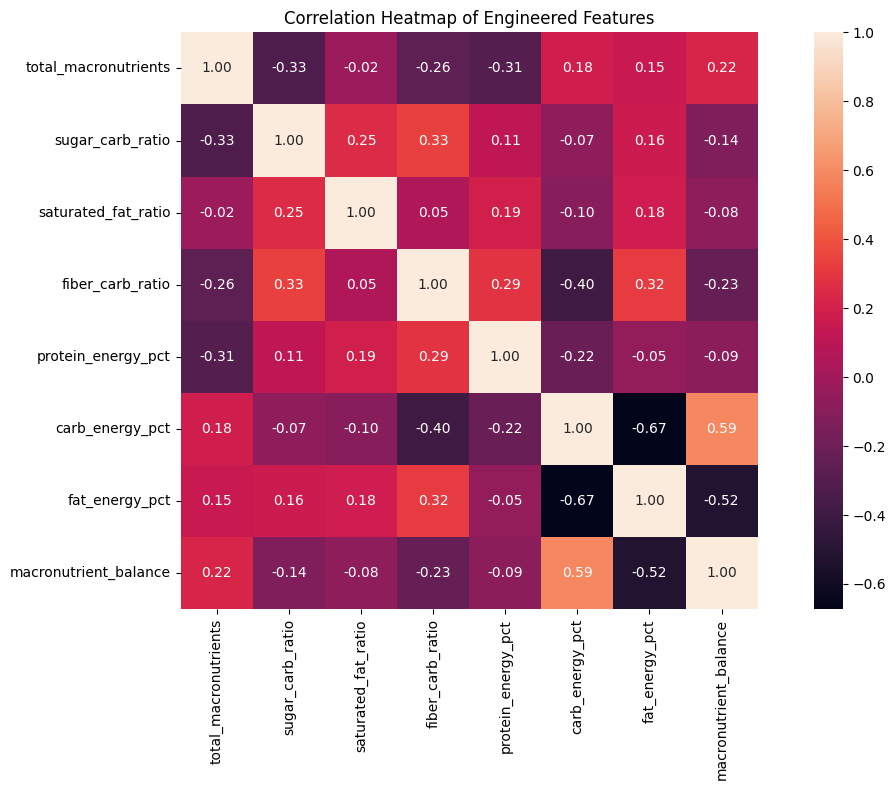

In [31]:
#CORRELATION ANALYSIS

correlation = df[engineered_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cbar=True,
    square=True
)

plt.title("Correlation Heatmap of Engineered Features")

plt.tight_layout()
plt.show()

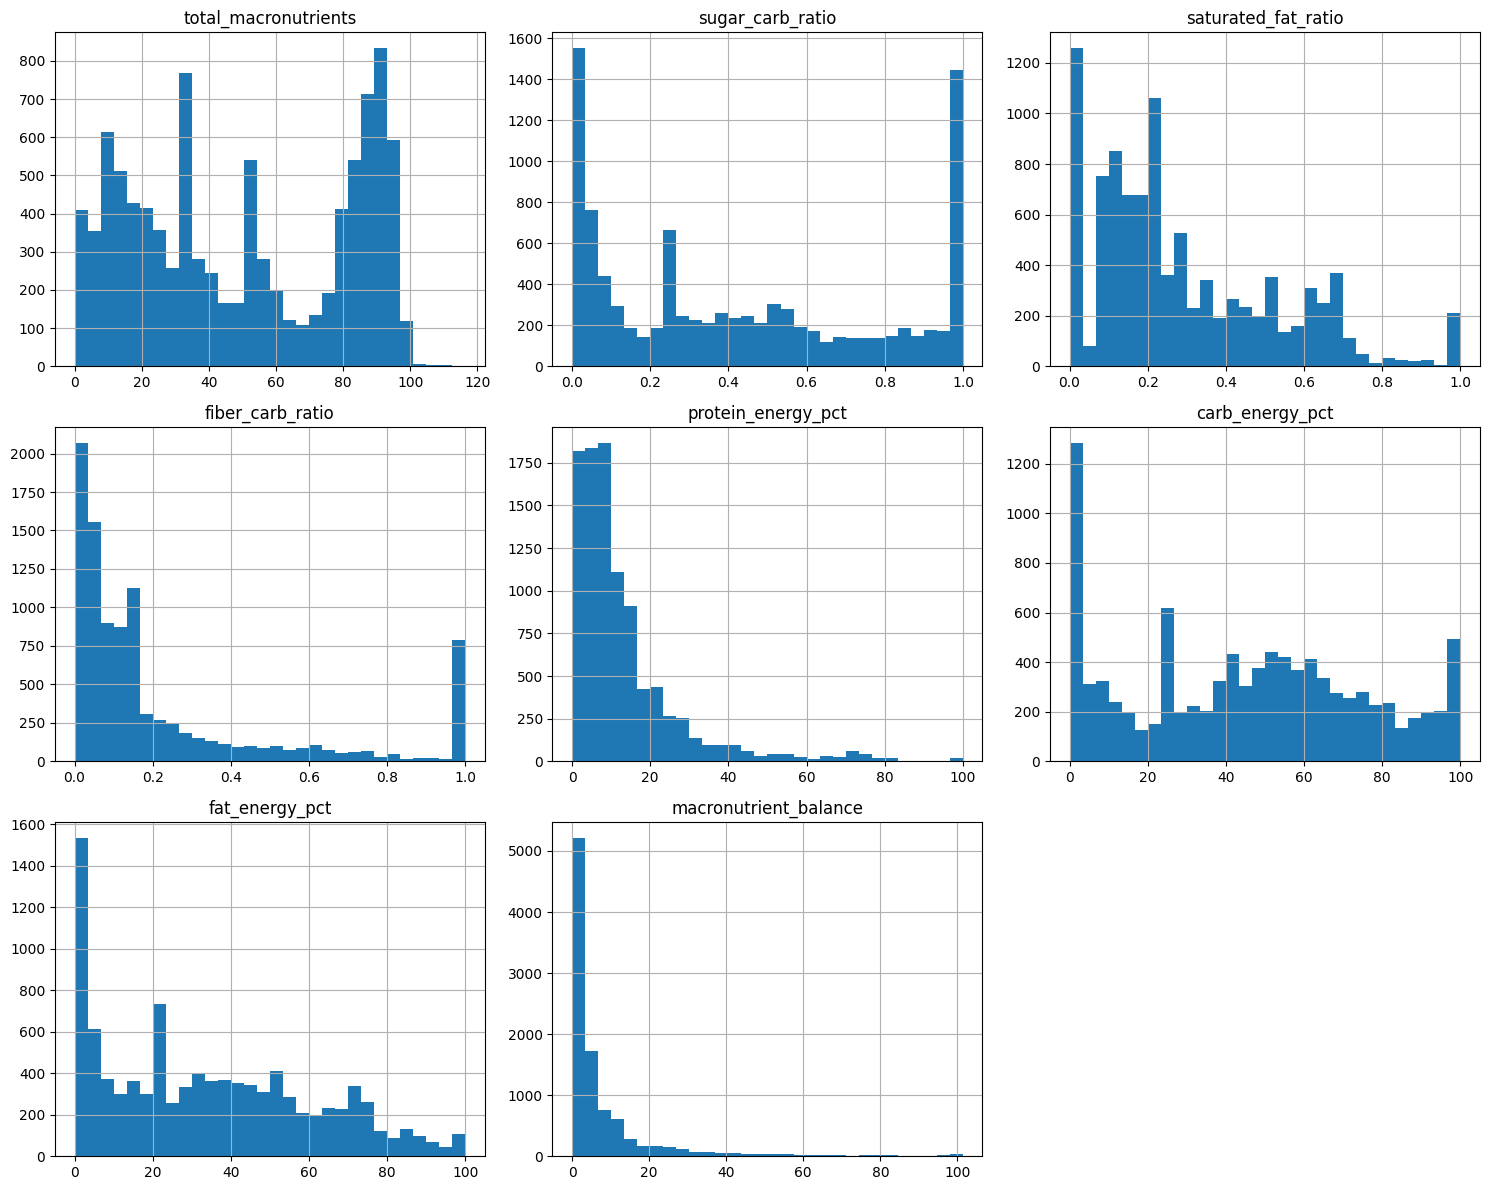

In [32]:
#FEATURE DISTRIBUTIONS
df[engineered_features].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [33]:
# FINAL PROJECT VERIFICATION
print("=" * 50)
print("FINAL WEEK 3 FEATURE ENGINEERING VERIFICATION")
print("=" * 50)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print(f"Engineered features: {len(engineered_features)}")

print("\nEngineered Features:")
for feature in engineered_features:
    print(f"✓ {feature}")

print("\nInfinite values:")
print(np.isinf(df[engineered_features]).sum().sum())

print("\n" + "=" * 50)
print("FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("=" * 50)

FINAL WEEK 3 FEATURE ENGINEERING VERIFICATION
Rows: 9771
Columns: 25
Missing values: 0
Duplicate rows: 0
Engineered features: 8

Engineered Features:
✓ total_macronutrients
✓ sugar_carb_ratio
✓ saturated_fat_ratio
✓ fiber_carb_ratio
✓ protein_energy_pct
✓ carb_energy_pct
✓ fat_energy_pct
✓ macronutrient_balance

Infinite values:
0

FEATURE ENGINEERING COMPLETED SUCCESSFULLY


In [34]:
#FINAL DATASET PREVIEW

display(df.head())

print("\nFinal dataset shape:")
print(df.shape)

,brands,countries,quantity,categories,labels,nutriscore_grade,ecoscore_grade,nova_group,energy-kcal_100g,fat_100g,...,salt_100g,sodium_100g,total_macronutrients,sugar_carb_ratio,saturated_fat_ratio,fiber_carb_ratio,protein_energy_pct,carb_energy_pct,fat_energy_pct,macronutrient_balance
0,سيدي علي,Morocco,33 cl,"Beverages and beverages preparations,Beverages...","Vegetarian, Vegan",a,not-applicable,4.0,0.0,0.00,...,0.000000,0.000000,4.20,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000
1,perly,"Morocco,United States",100 g,"Dairies,Fermented foods,Fermented milk product...","Vegetarian, Vegan",unknown,b,3.0,97.0,3.00,...,0.390000,0.156000,20.40,0.446809,0.500000,0.308511,32.989691,38.762887,27.835052,4.350000
2,Sidi Ali,Morocco,2 L,"Beverages and beverages preparations,Beverages...",Green Dot,a,not-applicable,1.0,280.0,7.02,...,0.065000,0.026000,31.22,0.233333,0.213675,0.161111,8.857143,25.714286,22.564286,3.017456
3,"Les Eaux Minérales d'oulmès,Sidi Ali",Morocco,"1,5 L","Beverages and beverages preparations,Beverages...","ISO 22000,ISO 14001,ISO 45001,ISO 9001",a,not-applicable,1.0,280.0,7.02,...,0.065000,0.026000,31.22,0.233333,0.213675,0.161111,8.857143,25.714286,22.564286,3.017456
4,AQUAFINA,المغرب,33cl,"Boissons et préparations de boissons,Boissons,...","Vegetarian, Vegan",a,not-applicable,4.0,0.0,0.00,...,0.000508,0.000203,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Final dataset shape:
(9771, 25)


In [35]:
#SAVE FINAL DATASET

output_file = "food_processing_feature_engineered.csv"

df.to_csv(
    output_file,
    index=False
)

print("======================================")
print("FINAL DATASET SAVED SUCCESSFULLY")
print("======================================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Infinite values:", np.isinf(df.select_dtypes(include=np.number)).sum().sum())

FINAL DATASET SAVED SUCCESSFULLY
Rows: 9771
Columns: 25
Missing values: 0
Duplicate rows: 0
Infinite values: 0


In [36]:
df.to_csv("food_processing_feature_engineered.csv", index=False)
print("Dataset exported successfully!")

Dataset exported successfully!
